# Metamer analysis

Per `hueexperiment.md`, a metamer candidate is a red/green grid point whose sensor response is close to the fixed-yellow response. This compares two distance models for the `RG` condition (red+green LEDs only, isolating the red+green half of the 10 Hz cycle):

- **Model A** (baseline-referenced): `RG`'s own `distance` column from `compute_trial_summary`, already used in earlier notebooks. Known to be insufficient since the baseline doesn't flicker.
- **Model B** (yellow-flash-referenced, required): distance from each `RG` grid point to the `Y` condition's mean response (`flash_Y.txt`, 100 repetitions of the fixed yellow stimulus, averaged into a single reference).

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from src.hue.io import load_session
from src.hue.analysis import compute_trial_summary, compute_reference, compute_distance_to_reference, compute_grid
from src.hue.plotting import plot_grid_heatmap

## 1. Load RG and Y conditions, compute the yellow reference

In [2]:
session_dir = repo_root / "data" / "hue" / "raw" / "data_17JUN26"
rg_df = load_session(session_dir / "flash_RG.txt")
y_df = load_session(session_dir / "flash_Y.txt")

rg_summary = compute_trial_summary(rg_df)
yellow_reference = compute_reference(y_df)
yellow_reference

meanHueR    1815.965517
meanHueG    1004.639683
meanHueB     619.169233
dtype: float64

## 2. Model B: distance to the yellow reference

In [3]:
rg_summary["distanceToYellow"] = compute_distance_to_reference(rg_summary, yellow_reference)
rg_summary[["trCnt", "currentRed", "currentGreen", "distance", "distanceToYellow"]].head()

,trCnt,currentRed,currentGreen,distance,distanceToYellow
0,1,0,0,3177.651737,1593.749941
1,2,0,222,3137.007892,1553.792623
2,3,355,0,2972.899379,1390.175923
3,4,0,444,3051.925766,1478.532215
4,5,355,222,2921.261201,1337.417256


## 3. Grid heatmaps: Model A vs Model B

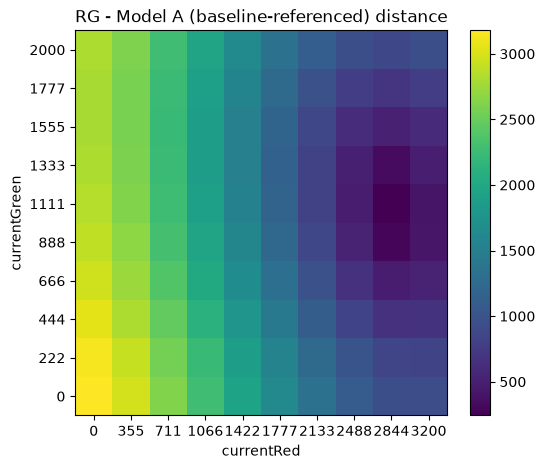

In [4]:
grid_model_a = compute_grid(rg_summary, "distance")
ax = plot_grid_heatmap(grid_model_a)
ax.set_title("RG - Model A (baseline-referenced) distance")
plt.show()

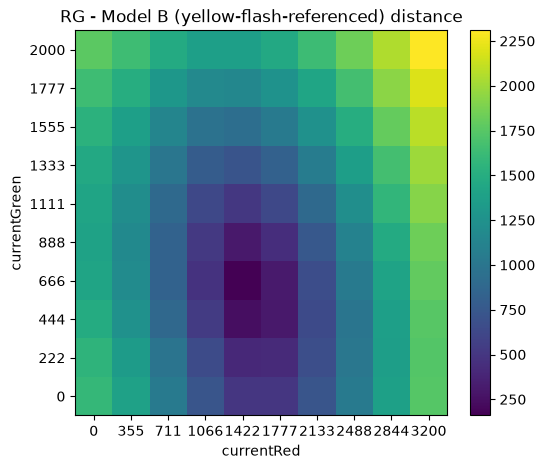

In [5]:
grid_model_b = compute_grid(rg_summary, "distanceToYellow")
ax = plot_grid_heatmap(grid_model_b)
ax.set_title("RG - Model B (yellow-flash-referenced) distance")
plt.show()